# 06 · Post-processing the detector boxes

**Goal:** turn the out-of-fold boxes of the 05 ensemble (3 detectors, flip TTA, WBF; out-of-fold score 0.2547) into the boxes we submit. **No model is trained here:** everything is chosen on the saved out-of-fold predictions of 04 (classifier) and 05 (detectors), and 07 applies it to their test predictions.

**Why this step.** In a usual project the detector's boxes are used as they come, and only the score threshold is tuned on validation data. Two things make more worthwhile here:
- **The metric** (general): a false box on an image without pneumonia costs that whole image, so which images get boxes matters as much as where the boxes are. This is the case for gating by the classifier.
- **The test labels** (specific to this competition): the test images were labelled by three radiologists, with the intersection of their boxes as the label; most training images by one. The test boxes are therefore smaller, and the test set has more positives. A detector trained and validated on single-reader labels cannot see this.

Section 1 shows both, with the sources and our own data.

**Questions**
1. Why post-process, and how do we know the test labels differ? (section 1)
2. Are our boxes too big or too small, and which ones? (section 3)
3. How much should the boxes shrink? (section 4)
4. Does gating by the classifier help? (section 5)
5. Everything together, against 05. (section 6)

Section 7 sums up and saves the settings for 07.

Needs `patients.csv` and `boxes.csv` from `scripts/prepare_data.py` (with `is_stage1_test` from 02), the out-of-fold boxes of the 05 detectors in `outputs/detection/` with their settings in `ensemble_256.json`, and the out-of-fold scores of the 04 classifier in `outputs/classification/stack_384/`.

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.metrics import f1_score, roc_auc_score

from rsna.boxes import nms, rank_scores, wbf
from rsna.metrics import BOX_COLS, iou, score_images
from rsna.paths import load_paths

pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", message="A worker stopped")  # joblib: harmless worker restarts

paths = load_paths()
DET = paths["outputs_dir"] / "detection"
patients = pd.read_csv(paths["processed_data_dir"] / "patients.csv")
true = pd.read_csv(paths["processed_data_dir"] / "boxes.csv")
ids = patients["patient_id"].to_numpy()
positive = patients["target"].to_numpy() == 1
fold_of = patients["fold"].to_numpy()
consensus = patients["is_stage1_test"].to_numpy()
SUBSETS = {"all": np.ones(len(ids), bool), "single reader": ~consensus, "consensus": consensus}
print(len(ids), "images:", (~consensus).sum(), "single reader,", consensus.sum(), "consensus (stage-1 test)")

26684 images: 25684 single reader, 1000 consensus (stage-1 test)


## 1. Why post-process, and why on two subsets

**The metric.** An image scores the mean over IoU thresholds 0.40–0.75 of TP / (TP + FP + FN), and the final score is the mean over the images. An image without true boxes scores 0 as soon as it gets one box, and is left out when it gets none. A false box on a negative image therefore costs a whole image. Whether an image gets boxes at all is a classification question, and the classifier of 04 answers it better than the detectors' top box score (out-of-fold AUC 0.905 vs 0.897): the case for gating (section 5). This holds for any data scored with this metric.

**The labels** ([Shih et al., 2019](https://escholarship.org/content/qt53d65470/qt53d65470.pdf), the dataset paper):
- Most training images were read by one radiologist, asked to draw each box as small as possible while covering the whole opacity.
- 4,527 images were read by three radiologists (two thoracic radiologists and one general radiologist). The class was the majority vote; a box drawn by only one reader stayed only if an adjudicator agreed; overlapping boxes were replaced by their **intersection**. 3,000 of these images became the final (stage-2) test set; the others went into the training set.
- The paper itself names this a limitation: the intersections made the test boxes smaller (mean area 51,063 vs 77,663 px² in training).

**What the top teams did:** all four shrank their boxes or used smaller ones, and chose how much on the stage-1 leaderboard, not on their validation data.

| place | boxes | also |
|---|---|---|
| 1st ([Pan, Cadrin-Chênevert](https://ajronline.org/doi/full/10.2214/AJR.19.21512)) | each edge shrunk by 12.5% | a lower threshold than the training data suggested |
| 2nd ([Gabruseva, Poplavskiy, Kalinin](https://arxiv.org/abs/2005.13899)) | 87.5% of the predicted size | |
| 3rd ([Cheng](https://github.com/pmcheng/rsna-pneumonia)) | 17% smaller in each dimension | a lower threshold; shrinking lowered his validation score but raised his leaderboard score |
| 4th ([16bit.ai / layer6](https://layer6.ai/wp-content/uploads/2018/12/16bit_layer6_RSNA_Pneumonia_Detection_Challenge_Winner_Documentation.pdf)) | the intersection of the models' boxes, mixed 3:1 with their mean | found their boxes still larger than the stage-1 test boxes |

**In our data.** 1,000 of the triple-read images, the stage-1 test set, are in our training set; 02 (section 5) found them and marked them `is_stage1_test`. The other 527 triple-read training images (4,527 − 3,000 − 1,000) cannot be told apart, so the *single reader* subset is mostly, not only, single-reader (about 2% triple-read). The stage-1 test images are our local stand-in for the test labels. Labels of the two subsets:

In [2]:
box_consensus = true["patient_id"].map(dict(zip(ids, consensus))).to_numpy()
box_masks = {"all": np.ones(len(true), bool), "single reader": ~box_consensus, "consensus": box_consensus}
labels = {}
for name, mask in SUBSETS.items():
    b = true[box_masks[name]]
    area = b["width"] * b["height"]
    labels[name] = {"images": mask.sum(), "Lung Opacity": positive[mask].mean(), "boxes per positive image": len(b) / positive[mask].sum(),
                    "mean area": area.mean(), "median area": area.median(), "mean width": b["width"].mean(), "mean height": b["height"].mean()}
label_table = pd.DataFrame(labels).T
ratio = (label_table.loc["consensus"] / label_table.loc["single reader"]).drop("images").rename("consensus / single reader")
pd.concat([label_table, ratio.to_frame().T]).astype({"images": "Int64"})

,images,Lung Opacity,boxes per positive image,mean area,median area,mean width,mean height
all,26684,0.2253,1.5893,77523.4480,64829.0000,218.4714,329.2697
single reader,25684,0.2203,1.5840,79332.6440,67157.0000,220.8454,334.1744
consensus,1000,0.3530,1.6742,50082.4450,40424.0000,182.4636,254.8782
consensus / single reader,<NA>,1.6021,1.0569,0.6313,0.6019,0.8262,0.7627


**Finding:** the consensus images have 60% more positives (35.3% vs 22.0%) and smaller boxes: mean area ×0.63, width ×0.83, height ×0.76, so the height shrinks more than the width. The areas match the paper (51,063 vs 77,663 px² for the whole test and training sets) and the 4th place's measurement.

**Consequence:** every result from here on is reported on both subsets, *single reader* (25,684 images, about 2% of them in fact triple-read) and *consensus* (the 1,000 stage-1 test images). The settings for the submissions are chosen on the consensus subset. It is small (353 positive images), so its intervals are wide; this is why 07 submits 3 shrink settings.

## 2. Setup: the 05 boxes and the classifier scores

The out-of-fold boxes of 05 rebuilt from `ensemble_256.json`: per model, NMS on the original and the flipped boxes, WBF of the two, rank scores within each fold; then the WBF of the 3 models. The out-of-fold pneumonia score of the 04 classifier (stacking of 4 models at 384, `outputs/classification/stack_384/`). Checks: 05's score 0.2547 and 04's AUC 0.9046:

In [3]:
ENSEMBLE = json.loads((DET / "ensemble_256.json").read_text())
THRESHOLDS = np.round(np.r_[np.arange(0.02, 0.10, 0.01), np.arange(0.10, 0.91, 0.05)], 2)
fold_of_id = dict(zip(ids, fold_of))


def nms_at(pred, iou):
    return pred if iou == "own" else nms(pred, iou)


def model_boxes(cfg, norm):
    """One detector, out-of-fold: NMS on both views, WBF of the two, then raw or rank scores (within each fold)."""
    views = [nms_at(pd.concat([pd.read_csv(DET / run / name) for run in cfg["runs"]], ignore_index=True), cfg["nms_iou"])
             for name in ("val_preds.csv", "val_preds_flip.csv")]
    p = wbf(views, iou_thr=cfg["tta_wbf_iou"])
    p = p.assign(fold=p["patient_id"].map(fold_of_id))
    return rank_scores(p, by="fold") if norm == "rank" else p


def threshold_scores(pred):
    """Per-image scores (thresholds, images) at every box threshold; NaN = image skipped by the metric."""
    return np.stack([score_images(true, pred[pred["confidence"] >= t], ids).to_numpy() for t in THRESHOLDS]).astype(np.float32)


def top_score(pred):
    """Image score: the highest box score of the image (0 without boxes)."""
    return pred.groupby("patient_id")["confidence"].max().reindex(ids, fill_value=0).to_numpy()


# "rank, w=(1, 1, 2), IoU 0.4" -> "rank", (1, 1, 2), 0.4
norm = ENSEMBLE["wbf"].split(", ", 1)[0]
weights = tuple(int(x) for x in ENSEMBLE["wbf"].split("(")[1].split(")")[0].split(", "))
wbf_iou = float(ENSEMBLE["wbf"].split("IoU ")[1])
per_model = Parallel(n_jobs=3)(delayed(model_boxes)(cfg, norm) for cfg in ENSEMBLE["models"].values())
boxes = wbf(per_model, weights, wbf_iou)
box_scores, box_top = threshold_scores(boxes), top_score(boxes)

classifier = pd.read_csv(paths["outputs_dir"] / "classification" / "stack_384" / "oof_preds.csv") \
    .set_index("patient_id").loc[ids, "p_pneumonia"].to_numpy()
t05 = ENSEMBLE["threshold"]
print(f"05 ensemble: {np.nanmean(box_scores[np.isclose(THRESHOLDS, t05)]):.4f} at threshold {t05} (05: {ENSEMBLE['oof_score']:.4f}); "
      f"classifier AUC {roc_auc_score(positive, classifier):.4f}")

05 ensemble: 0.2547 at threshold 0.8 (05: 0.2547); classifier AUC 0.9046


**The two subsets** with the 05 settings (box threshold 0.8) and at each subset's best threshold. *score, positives*: mean score of the images with true boxes; *negatives with a box*: share of the images without true boxes that get one (each scores 0). AUC and F1 from the image's top box score (F1 at the box threshold), and of the classifier (F1 at 0.5):

In [4]:
def subset_table(scores, top, threshold):
    ti = np.flatnonzero(np.isclose(THRESHOLDS, threshold))[0]
    rows = {}
    for name, mask in SUBSETS.items():
        mean = np.nanmean(scores[:, mask], axis=1)
        rows[name] = {"score": mean[ti], "score, positives": np.nanmean(scores[ti, mask & positive]),
                      "negatives with a box": (top[mask & ~positive] >= threshold).mean(),
                      "best threshold": THRESHOLDS[mean.argmax()], "score (best threshold)": mean.max(),
                      "AUC": roc_auc_score(positive[mask], top[mask]), "F1": f1_score(positive[mask], top[mask] >= threshold),
                      "classifier AUC": roc_auc_score(positive[mask], classifier[mask]),
                      "classifier F1": f1_score(positive[mask], classifier[mask] >= 0.5)}
    return pd.DataFrame(rows).T


subset_table(box_scores, box_top, t05)

,score,"score, positives",negatives with a box,best threshold,score (best threshold),AUC,F1,classifier AUC,classifier F1
all,0.2547,0.3528,0.1120,0.8,0.2547,0.8968,0.6658,0.9046,0.6566
single reader,0.2587,0.3629,0.1138,0.8,0.2587,0.8971,0.6659,0.9049,0.6582
consensus,0.1727,0.1908,0.0572,0.6,0.2336,0.9271,0.6644,0.9335,0.6266


**Finding:**
- The 05 ensemble scores much lower on the consensus images: 0.1727 vs 0.2587 at threshold 0.8. It is not the classification: it separates these images better (AUC 0.927 vs 0.897) and puts a box on fewer of their negatives (5.7% vs 11.4%). The loss is on the positive images, 0.191 vs 0.363: our boxes do not fit the smaller consensus boxes (sections 3–4).
- The consensus images want a lower box threshold: 0.6 scores 0.2336 (+0.061), while 0.8 stays best on the single-reader images. The 1st and 3rd places also lowered their threshold for the test set; with 35% positives, a missed opacity costs more than with 22%.
- The classifier separates the images better than the detectors' top box score on both subsets (AUC 0.905 vs 0.897, and 0.934 vs 0.927). Its F1 at 0.5 is lower on the consensus images (0.627): with more positives a lower cut-off would fit (section 5).

## 3. Are our boxes too big?

Each true box is paired with the predicted box of its image that overlaps it most (boxes at the 05 threshold 0.8), if their IoU is above 0.3. Pairs below that are left out, so very wrong sizes do not show here; they are what the metric counts as misses. Per pair: predicted / true width, height and area, and the shift of the predicted centre, as a share of the true width (x) and height (y). Medians per subset:

In [5]:
def pair_boxes(pred, threshold, min_iou=0.3):
    """Each true box with the predicted box (score >= threshold) of its image that overlaps it most, if IoU > min_iou."""
    p = pred[pred["confidence"] >= threshold]
    t_xywh, p_xywh = true[BOX_COLS].to_numpy(float), p[BOX_COLS].to_numpy(float)
    p_rows = p.groupby("patient_id").indices
    t_idx, p_idx, overlap = [], [], []
    for pid, ti in true.groupby("patient_id").indices.items():
        pi = p_rows.get(pid)
        if pi is None:
            continue
        o = iou(t_xywh[ti], p_xywh[pi])
        j = o.argmax(1)
        best = o[np.arange(len(ti)), j]
        keep = best > min_iou
        t_idx += list(ti[keep])
        p_idx += list(pi[j[keep]])
        overlap += list(best[keep])
    t, q = t_xywh[t_idx], p_xywh[p_idx]
    return pd.DataFrame({"consensus": box_consensus[t_idx], "IoU": overlap, "true area": t[:, 2] * t[:, 3],
                         "width": q[:, 2] / t[:, 2], "height": q[:, 3] / t[:, 3], "area": q[:, 2] * q[:, 3] / (t[:, 2] * t[:, 3]),
                         "shift x": (q[:, 0] + q[:, 2] / 2 - t[:, 0] - t[:, 2] / 2) / t[:, 2],
                         "shift y": (q[:, 1] + q[:, 3] / 2 - t[:, 1] - t[:, 3] / 2) / t[:, 3]})


pairs = pair_boxes(boxes, t05)
pairs["subset"] = np.where(pairs["consensus"], "consensus", "single reader")
n_true = {"single reader": (~box_consensus).sum(), "consensus": box_consensus.sum()}
size_table = pairs.groupby("subset").agg(pairs=("IoU", "size"), IoU=("IoU", "median"), width=("width", "median"),
                                         height=("height", "median"), area=("area", "median"),
                                         larger=("area", lambda a: (a > 1).mean()), **{"shift x": ("shift x", "median"),
                                         "shift y": ("shift y", "median")})
size_table.insert(1, "share of true boxes", size_table["pairs"] / pd.Series(n_true))
size_table.rename(columns={"larger": "area ratio > 1"})

,pairs,share of true boxes,IoU,width,height,area,area ratio > 1,shift x,shift y
subset,,,,,,,,,
consensus,250,0.4230,0.5777,1.2330,1.2537,1.5990,0.8200,-0.0037,-0.0533
single reader,5537,0.6177,0.6703,1.0029,1.0225,1.0199,0.5189,-0.0024,-0.0013


Distribution of the width and height ratios (log scale; 1 = the true size):

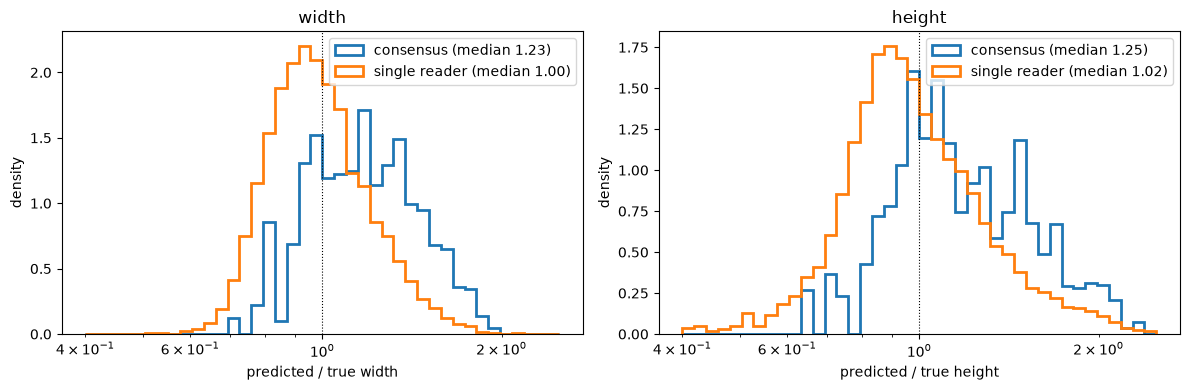

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.logspace(np.log10(0.4), np.log10(2.5), 41)
for ax, col in zip(axes, ["width", "height"]):
    for name, g in pairs.groupby("subset"):
        ax.hist(g[col], bins=bins, density=True, histtype="step", lw=2, label=f"{name} (median {g[col].median():.2f})")
    ax.axvline(1, color="k", lw=0.8, ls=":")
    ax.set(xscale="log", xlabel=f"predicted / true {col}", ylabel="density", title=col)
    ax.legend()
plt.tight_layout()

**By box size:** median width and height ratio in 3 equal groups of the true box area, and of the predicted box area (group edges from all pairs). Grouped by the true size, small boxes look over-predicted and large ones under-predicted partly by chance (regression to the mean); only the predicted size is known at test time, so a size-dependent correction could only use that:

In [7]:
pairs["pred area"] = pairs["true area"] * pairs["area"]
by_size = {by: pairs.assign(group=pd.qcut(pairs[f"{by} area"], 3, labels=["small", "medium", "large"]))
           .groupby(["subset", "group"], observed=True).agg(pairs=("IoU", "size"), width=("width", "median"), height=("height", "median"))
           for by in ("true", "pred")}
pd.concat(by_size, axis=1, names=["grouped by"]).rename(columns={"true": "true box", "pred": "predicted box"}, level=0)

grouped by           true box                 predicted box                
                        pairs   width  height         pairs   width  height
subset        group                                                        
consensus     small       148  1.3579  1.4471            78  1.1879  1.2352
              medium       66  1.1584  1.1044            88  1.2465  1.2370
              large        36  0.9699  0.9523            84  1.2825  1.3141
single reader small      1781  1.1766  1.3239          1851  0.9914  1.0163
              medium     1863  1.0009  1.0249          1841  0.9963  1.0171
              large      1893  0.9055  0.8845          1845  1.0188  1.0342

**Finding:**
- On the single-reader images our boxes have the right size: median width ×1.00, height ×1.02, about half of them larger than the true box and half smaller. The detectors learned these labels well.
- On the consensus images the same boxes are too big: width ×1.23, height ×1.25, area ×1.60, and 82% are larger than the true box. Only 42% of the consensus true boxes get a predicted box with IoU > 0.3 (single reader 62%). This is the label gap of section 1 (consensus boxes ×0.83 as wide and ×0.76 as high).
- The centres are right: shifted by less than 1% of the box width, and by 5% of the box height upward on the consensus images.
- Grouped by the predicted size, the ratio hardly changes from small to large boxes (single reader 0.99–1.03, consensus 1.19–1.31); the trend by true size is mostly regression to the mean. One shrink factor for the width and one for the height should be enough; a size-dependent correction is not needed. The medians suggest about 0.8 for both on the consensus images; section 4 measures it with the metric.

## 4. How much should the boxes shrink?

Every box is scaled around its centre: width × *sx*, height × *sy*, each 0.60–1.05 in steps of 0.05 (100 settings), at every box threshold. Shrinking changes only the images with true boxes: an image without them scores 0 with any box and is skipped without, whatever the box size, so only the positive images are scored again.

- **split-half:** as in 05, the setting and threshold are picked on a random half of the subset's images and scored on the other half (20 splits × both halves).
- **Paired bootstrap** (2,000 resamples of the subset's images): the best shrink minus no shrink, each at its best threshold on that subset.

In [8]:
SHRINKS = np.round(np.arange(0.60, 1.051, 0.05), 2)
GRID = [(sx, sy) for sx in SHRINKS for sy in SHRINKS]
pos_ids = ids[positive]
pos_boxes = boxes[boxes["patient_id"].isin(set(pos_ids))]


def shrink(pred, sx, sy):
    """Boxes scaled around their centre: width x sx, height x sy."""
    w, h = pred["width"] * sx, pred["height"] * sy
    return pred.assign(x=pred["x"] + (pred["width"] - w) / 2, y=pred["y"] + (pred["height"] - h) / 2, width=w, height=h)


def positive_scores(pred, sx, sy):
    p = shrink(pred, sx, sy)
    return np.stack([score_images(true, p[p["confidence"] >= t], pos_ids).to_numpy() for t in THRESHOLDS]).astype(np.float32)


# (settings, thresholds, images): negatives as without shrinking, positives scored again (8 processes)
shrink_scores = np.repeat(box_scores[None], len(GRID), axis=0)
shrink_scores[:, :, positive] = np.stack(Parallel(n_jobs=8)(delayed(positive_scores)(pos_boxes, sx, sy) for sx, sy in GRID))
NO_SHRINK = GRID.index((1.0, 1.0))
assert np.allclose(shrink_scores[NO_SHRINK], box_scores, equal_nan=True)

**Same shrink for width and height** (*sx* = *sy*): score at the best threshold of each setting, per subset:

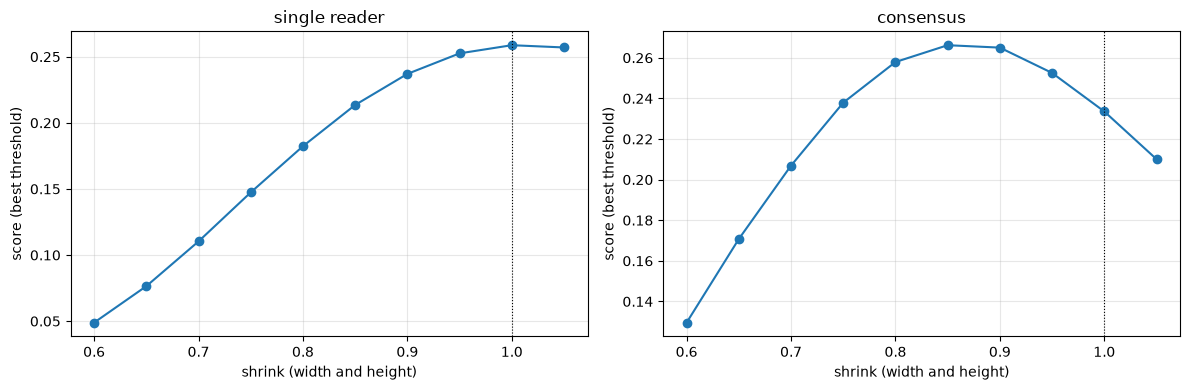

In [9]:
uniform = [GRID.index((s, s)) for s in SHRINKS]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ["single reader", "consensus"]):
    mean = np.nanmean(shrink_scores[:, :, SUBSETS[name]], axis=2)
    ax.plot(SHRINKS, mean[uniform].max(1), "o-")
    ax.axvline(1, color="k", lw=0.8, ls=":")
    ax.set(xlabel="shrink (width and height)", ylabel="score (best threshold)", title=name)
    ax.grid(alpha=0.3)
plt.tight_layout()

**Width and height separately**, consensus images: score at the best threshold of each setting:

In [10]:
consensus_best = np.nanmean(shrink_scores[:, :, consensus], axis=2).max(1)
pd.DataFrame(consensus_best.reshape(len(SHRINKS), len(SHRINKS)), index=pd.Index(SHRINKS, name="sx (width)"),
             columns=pd.Index(SHRINKS, name="sy (height)")).style.format("{:.4f}").background_gradient(axis=None)

sy (height),0.600000,0.650000,0.700000,0.750000,0.800000,0.850000,0.900000,0.950000,1.000000,1.050000
sx (width),,,,,,,,,,
0.600000,0.1296,0.1486,0.1625,0.1755,0.1840,0.1853,0.1868,0.1830,0.1777,0.1665
0.650000,0.1510,0.1707,0.1882,0.2004,0.2083,0.2136,0.2142,0.2124,0.2067,0.1935
0.700000,0.1674,0.1892,0.2069,0.2225,0.2326,0.2355,0.2380,0.2333,0.2279,0.2158
0.750000,0.1801,0.2024,0.2230,0.2379,0.2473,0.2532,0.2538,0.2503,0.2420,0.2310
0.800000,0.1907,0.2121,0.2328,0.2465,0.2579,0.2618,0.2630,0.2597,0.2503,0.2402
0.850000,0.1929,0.2165,0.2374,0.2510,0.2604,0.2662,0.2685,0.2633,0.2550,0.2446
0.900000,0.1909,0.2133,0.2336,0.2497,0.2599,0.2661,0.2650,0.2609,0.2523,0.2429
0.950000,0.1847,0.2083,0.2255,0.2430,0.2546,0.2575,0.2580,0.2525,0.2437,0.2343
1.000000,0.1754,0.1971,0.2173,0.2300,0.2404,0.2464,0.2454,0.2397,0.2336,0.2217


**The best setting of each subset**, and how it scores on the other subset (at the threshold picked on its own subset). *split-half* for the subset it was picked on:

In [11]:
def split_half(arr, n_splits=20):
    """arr (settings, thresholds, images): mean held-out score when setting and threshold are picked on the other half."""
    rng, held = np.random.default_rng(0), []
    for _ in range(n_splits):
        perm = rng.permutation(arr.shape[2])
        halves = perm[: len(perm) // 2], perm[len(perm) // 2:]
        for a, b in (halves, halves[::-1]):
            mean = np.nanmean(arr[:, :, a], axis=2)
            i, j = np.unravel_index(mean.argmax(), mean.shape)
            held.append(np.nanmean(arr[i, j, b]))
    return np.mean(held)


def best_on(mask, settings=range(len(GRID))):
    """Best (setting, threshold index) among `settings` on the images in mask."""
    settings = list(settings)
    mean = np.nanmean(shrink_scores[settings][:, :, mask], axis=2)
    si, ti = np.unravel_index(mean.argmax(), mean.shape)
    return settings[si], ti


chosen = {"no shrink, single reader": best_on(~consensus, [NO_SHRINK]), "no shrink, consensus": best_on(consensus, [NO_SHRINK]),
          "best, single reader": best_on(~consensus), "best, consensus": best_on(consensus)}
rows = {}
for name, (si, ti) in chosen.items():
    picked_on = consensus if name.endswith("consensus") else ~consensus
    rows[name] = {"sx": GRID[si][0], "sy": GRID[si][1], "threshold": THRESHOLDS[ti],
                  "score, single reader": np.nanmean(shrink_scores[si, ti, ~consensus]),
                  "score, consensus": np.nanmean(shrink_scores[si, ti, consensus]),
                  "split-half": split_half(shrink_scores[:, :, picked_on]) if name.startswith("best") else np.nan}
pd.DataFrame(rows).T.rename_axis("setting picked on")

,sx,sy,threshold,"score, single reader","score, consensus",split-half
setting picked on,,,,,,
"no shrink, single reader",1.00,1.0,0.8,0.2587,0.1727,NaN
"no shrink, consensus",1.00,1.0,0.6,0.2112,0.2336,NaN
"best, single reader",1.00,1.0,0.8,0.2587,0.1727,0.2587
"best, consensus",0.85,0.9,0.6,0.1816,0.2685,0.2616


Best shrink minus no shrink, paired bootstrap on each subset's images:

In [12]:
def interval(a, b, n=2000):
    samples = np.random.default_rng(0).integers(0, len(a), (n, len(a)), dtype=np.int32)
    d = np.nanmean(a[samples], axis=1) - np.nanmean(b[samples], axis=1)
    low, high = np.percentile(d, [2.5, 97.5])
    return {"difference": np.nanmean(a) - np.nanmean(b), "95% interval": f"[{low:.4f}, {high:.4f}]"}


pd.DataFrame({name: interval(shrink_scores[(*chosen[f"best, {name}"], mask)], shrink_scores[(*chosen[f"no shrink, {name}"], mask)])
              for name, mask in [("single reader", ~consensus), ("consensus", consensus)]}).T.rename_axis("best shrink minus none")

,difference,95% interval
best shrink minus none,,
single reader,0.0,"[0.0000, 0.0000]"
consensus,0.035,"[0.0229, 0.0477]"


**Finding:**
- **Single reader:** no shrink is best (1.00 × 1.00, threshold 0.8). Every shrink lowers the score; the boxes already have the size of these labels.
- **Consensus:** best at width × 0.85, height × 0.90, threshold 0.6: 0.2685, against 0.2336 without shrinking at its best threshold (+0.035, 95% interval [0.023, 0.048]). On the single-reader images the same setting scores 0.1816 (−0.077): the gain comes from the label style, not from better boxes.
- **split-half** 0.2616, 0.007 below the in-sample score; it covers the shrink and threshold only (section 6 estimates the whole selection). The surface is flat near the top: width 0.80–0.90 × height 0.85–0.90 all score within 0.008 of the best. With the same factor for both, 0.85 (0.2662) and 0.90 (0.2650) are nearly equal, on either side of the 0.875 of the 1st and 2nd places.
- The medians of section 3 suggested about 0.8; the metric prefers a little less shrinking, since it counts any IoU from 0.40 up as a match, and a box shrunk too much loses small true boxes.
- **For 07:** the 3 submissions span this flat region. A proposal: 0.85 × 0.90 (the best here, 0.2685), 0.80 × 0.85 (stronger, 0.2618, in case the test boxes are smaller still) and 0.90 × 0.95 (milder, 0.2609). The threshold is chosen again after gating (section 5).

## 5. Does gating by the classifier help?

Up to here the box threshold alone decides which images get boxes, and the 04 classifier ranks the images better than the top box score (section 2). Two ways to use it, each subset with its own shrink from section 4 (single reader: none; consensus: 0.85 × 0.90):
- **Hard:** an image keeps its boxes only if its classifier score is at least a cut-off (0.05–0.95; 0 = no gating), with the box threshold chosen together with the cut-off. No new scoring is needed: a gated image scores 0 if it has true boxes and is skipped if not.
- **Soft:** every box score becomes box^(1−w) × classifier^w (w = 0.25, 0.5, 0.75; 0 = no gating), followed by one threshold. Within an image the boxes keep their order; between images the classifier moves the scores.

split-half and paired bootstrap as in section 4.

In [13]:
CUTOFFS = np.round(np.r_[0, np.arange(0.05, 0.96, 0.05)], 2)
WEIGHTS = [0, 0.25, 0.5, 0.75]
SHRINK_OF = {"single reader": chosen["best, single reader"][0], "consensus": chosen["best, consensus"][0]}
MASK_OF = {"single reader": ~consensus, "consensus": consensus}
clf_of_id = dict(zip(ids, classifier))


def hard_gate(scores, cutoff):
    """scores (thresholds, images): images with classifier < cutoff get no boxes (positives score 0, negatives are skipped)."""
    return np.where(classifier >= cutoff, scores, np.where(positive, 0, np.nan)).astype(np.float32)


def soft_scores(si, w):
    p = shrink(boxes, *GRID[si])
    return threshold_scores(p.assign(confidence=p["confidence"] ** (1 - w) * p["patient_id"].map(clf_of_id) ** w))


# (settings, thresholds, images) per subset; soft: w = 0 is the ungated boxes, the others are scored again (6 processes)
hard = {name: np.stack([hard_gate(shrink_scores[si], c) for c in CUTOFFS]) for name, si in SHRINK_OF.items()}
jobs = [(name, w) for name in SHRINK_OF for w in WEIGHTS[1:]]
done = dict(zip(jobs, Parallel(n_jobs=6)(delayed(soft_scores)(SHRINK_OF[name], w) for name, w in jobs)))
soft = {name: np.stack([shrink_scores[si]] + [done[name, w] for w in WEIGHTS[1:]]) for name, si in SHRINK_OF.items()}

**Hard gating:** score at the best box threshold for each cut-off (0 = no gating), on each subset:

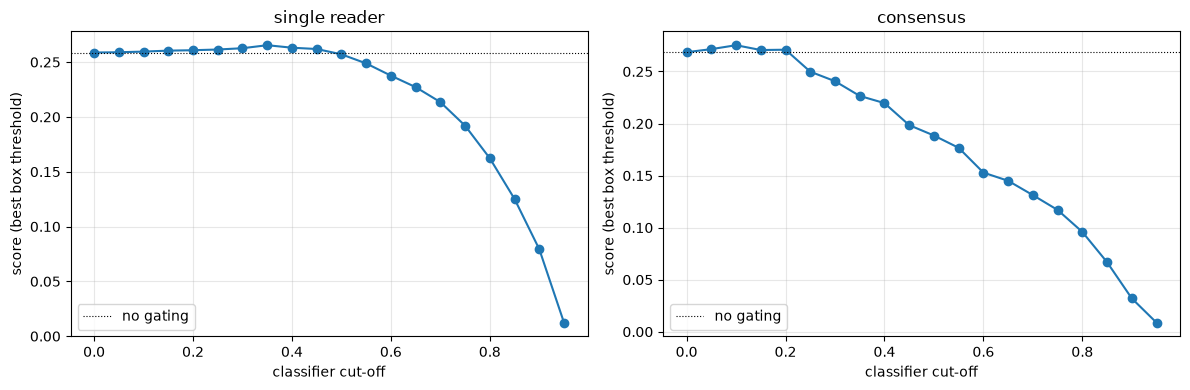

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, mask) in zip(axes, MASK_OF.items()):
    mean = np.nanmean(hard[name][:, :, mask], axis=2)
    ax.plot(CUTOFFS, mean.max(1), "o-")
    ax.axhline(mean[0].max(), color="k", lw=0.8, ls=":", label="no gating")
    ax.set(xlabel="classifier cut-off", ylabel="score (best box threshold)", title=name)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()

**Best of each kind on each subset.** *boxed images*: share of the images that get at least one box; *F1* of that decision against the label. *AUC, ranking score*: of the score that ranks the images, the top box score without gating and the top combined score with soft gating. With hard gating the decision needs two scores (box and classifier) and has no single AUC; the column gives the classifier's alone:

In [15]:
def pick(arr, mask):
    mean = np.nanmean(arr[:, :, mask], axis=2)
    return np.unravel_index(mean.argmax(), mean.shape)


rows, best = {}, {}
for name, mask in MASK_OF.items():
    for kind, arr in [("no gating", hard[name][:1]), ("hard", hard[name]), ("soft", soft[name])]:
        i, j = pick(arr, mask)
        t = THRESHOLDS[j]
        if kind == "soft":
            w = WEIGHTS[i]
            image_score, boxed, setting = box_top ** (1 - w) * classifier ** w, box_top ** (1 - w) * classifier ** w >= t, f"w = {w}"
        else:
            c = CUTOFFS[i]
            image_score = box_top if kind == "no gating" else classifier
            boxed, setting = (box_top >= t) & (classifier >= c), "" if kind == "no gating" else f"cut-off {c}"
        best[name, kind] = arr[i, j]
        rows[name, kind] = {"setting": setting, "box threshold": t, "score": np.nanmean(arr[i, j, mask]),
                            "split-half": split_half(arr[:, :, mask]), "boxed images": boxed[mask].mean(),
                            "F1": f1_score(positive[mask], boxed[mask]), "AUC, ranking score": roc_auc_score(positive[mask], image_score[mask])}
pd.DataFrame(rows).T.rename_axis(["subset", "gating"])

setting box threshold   score split-half boxed images      F1 AUC, ranking score
subset        gating                                                                                          
single reader no gating                         0.8  0.2587     0.2587        0.243  0.6659             0.8971
              hard       cut-off 0.35          0.75  0.2654     0.2651       0.2316  0.6788             0.9049
              soft           w = 0.25           0.7  0.2606     0.2597       0.2088   0.672             0.9063
consensus     no gating                         0.6  0.2685     0.2645        0.421  0.8088             0.9271
              hard        cut-off 0.1           0.6  0.2753     0.2697         0.39  0.8183             0.9335
              soft              w = 0           0.6  0.2685     0.2617        0.421  0.8088             0.9271

Best gating minus no gating, paired bootstrap on each subset's images:

In [16]:
pd.DataFrame({(name, kind): interval(best[name, kind][mask], best[name, "no gating"][mask])
              for name, mask in MASK_OF.items() for kind in ("hard", "soft")}).T.rename_axis(["subset", "minus no gating"])

difference       95% interval
subset        minus no gating                              
single reader hard                0.0067   [0.0028, 0.0106]
              soft                0.0019  [-0.0021, 0.0060]
consensus     hard                0.0067  [-0.0009, 0.0144]
              soft                   0.0   [0.0000, 0.0000]

**Finding:**
- **Hard gating helps a little.** Single reader: cut-off 0.35 with box threshold 0.75, +0.0067 (95% interval [0.003, 0.011]), split-half 0.2651 vs 0.2587. Consensus: cut-off 0.1 with box threshold 0.6, also +0.0067, but the interval includes 0 ([−0.001, 0.014]); split-half 0.2697 vs 0.2645 (both with the shrink picked on all consensus images in section 4).
- The best cut-off is lower on the consensus images (0.1 vs 0.35). They have more positives (35% vs 22%), so it costs more to drop an image there. Above 0.2 the consensus score falls quickly; between 0 and 0.2 every cut-off is at least as good as no gating.
- **Soft gating does not help:** +0.002 on single reader (interval includes 0); on consensus the best weight is 0, i.e. no gating.
- Image decision (box or not): F1 0.809 → 0.818 on consensus, 0.666 → 0.679 on single reader. The classifier ranks the images better than the top box score (AUC 0.934 vs 0.927 on consensus, 0.905 vs 0.897 on single reader), but the gated decision uses both scores and has no single AUC.
- **For 07:** hard gating at cut-off 0.1 with box threshold 0.6, picked on the consensus subset. The gain is small and uncertain, but the risk is low.

## 6. Everything together, against 05

The steps added one at a time to the 05 boxes, each picked on the consensus images: the box threshold, the shrink (section 4), the hard gating (section 5). **A** is the full chain; **B** and **C**, the other two submissions, differ from it only in the shrink (0.05 stronger and 0.05 milder in both directions). The consensus scores are in-sample, since everything was picked on these images; a held-out estimate of the whole selection follows the table. *F1*: the image decision (box or not). The steps change where the images are cut, not how they are ranked: AUC of the top box score 0.897 (single reader) / 0.927 (consensus), of the classifier 0.905 / 0.934 (sections 2 and 5):

In [17]:
def setting_index(sx, sy):
    return next(i for i, g in enumerate(GRID) if np.allclose(g, (sx, sy)))


def config_scores(sx, sy, threshold, cutoff):
    """Per-image scores: boxes shrunk by (sx, sy), box threshold, classifier cut-off (0 = no gating)."""
    return hard_gate(shrink_scores[setting_index(sx, sy)], cutoff)[np.flatnonzero(np.isclose(THRESHOLDS, threshold))[0]]


sx, sy = GRID[SHRINK_OF["consensus"]]
ci, tj = pick(hard["consensus"], consensus)
cut, thr = float(CUTOFFS[ci]), float(THRESHOLDS[tj])
SUBMISSIONS = {k: (round(sx + d, 2), round(sy + d, 2)) for k, d in [("A", 0), ("B", -0.05), ("C", 0.05)]}
configs = {"05": (1.0, 1.0, t05, 0), f"+ threshold {thr}": (1.0, 1.0, thr, 0), f"+ shrink {sx} × {sy}": (sx, sy, thr, 0),
           f"+ gating {cut} (A)": (*SUBMISSIONS["A"], thr, cut),
           **{f"{k}: shrink {a} × {b}": (a, b, thr, cut) for k, (a, b) in SUBMISSIONS.items() if k != "A"}}
config_table = {}
for name, (a, b, t, c) in configs.items():
    s, boxed = config_scores(a, b, t, c), (box_top >= t) & (classifier >= c)
    row = {"sx": a, "sy": b, "box threshold": t, "cut-off": c}
    row |= {f"score, {sub}": np.nanmean(s[mask]) for sub, mask in SUBSETS.items()}
    row |= {f"F1, {sub}": f1_score(positive[mask], boxed[mask]) for sub, mask in MASK_OF.items()}
    config_table[name] = row
pd.DataFrame(config_table).T

,sx,sy,box threshold,cut-off,"score, all","score, single reader","score, consensus","F1, single reader","F1, consensus"
05,1.00,1.00,0.8,0.0,0.2547,0.2587,0.1727,0.6659,0.6644
+ threshold 0.6,1.00,1.00,0.6,0.0,0.2121,0.2112,0.2336,0.6100,0.8088
+ shrink 0.85 × 0.9,0.85,0.90,0.6,0.0,0.1849,0.1816,0.2685,0.6100,0.8088
+ gating 0.1 (A),0.85,0.90,0.6,0.1,0.1947,0.1914,0.2753,0.6333,0.8183
B: shrink 0.8 × 0.85,0.80,0.85,0.6,0.1,0.1710,0.1671,0.2681,0.6333,0.8183
C: shrink 0.9 × 0.95,0.90,0.95,0.6,0.1,0.2113,0.2091,0.2668,0.6333,0.8183


**A minus 05 per fold**, on each subset (about 200 consensus images per fold):

In [18]:
final, base = config_scores(*configs[f"+ gating {cut} (A)"]), config_scores(*configs["05"])
per_fold = {}
for k in range(5):
    f = fold_of == k
    per_fold[k] = {"consensus images": (f & consensus).sum(), "05, consensus": np.nanmean(base[f & consensus]),
                   "A, consensus": np.nanmean(final[f & consensus]),
                   "A − 05, consensus": np.nanmean(final[f & consensus]) - np.nanmean(base[f & consensus]),
                   "A − 05, single reader": np.nanmean(final[f & ~consensus]) - np.nanmean(base[f & ~consensus])}
pd.DataFrame(per_fold).T.rename_axis("fold").astype({"consensus images": int})

,consensus images,"05, consensus","A, consensus","A − 05, consensus","A − 05, single reader"
fold,,,,,
0,196,0.1509,0.2920,0.1411,-0.0690
1,186,0.1761,0.2650,0.0888,-0.0792
2,216,0.1779,0.2732,0.0953,-0.0617
3,211,0.1749,0.2797,0.1048,-0.0575
4,191,0.1856,0.2638,0.0782,-0.0678


A minus 05, paired bootstrap on each subset's images:

In [19]:
pd.DataFrame({sub: interval(final[mask], base[mask]) for sub, mask in SUBSETS.items()}).T.rename_axis("A minus 05")

,difference,95% interval
A minus 05,,
all,-0.06,"[-0.0654, -0.0543]"
single reader,-0.0673,"[-0.0730, -0.0616]"
consensus,0.1025,"[0.0764, 0.1300]"


**Held-out estimate of the whole selection:** shrink, box threshold and cut-off picked together on a random half of the consensus images and scored on the other half (20 splits × both halves). For comparison the same with the 05 boxes, threshold only:

In [20]:
cons = shrink_scores[:, :, consensus]  # (shrinks, thresholds, consensus images)
joint = np.concatenate([np.where(classifier[consensus] >= c, cons, np.where(positive[consensus], 0, np.nan)).astype(np.float32)
                        for c in CUTOFFS])  # (cut-offs x shrinks, thresholds, images)
print(f"whole selection: {split_half(joint):.4f} (in-sample {np.nanmean(final[consensus]):.4f}); "
      f"05 boxes, threshold only: {split_half(cons[NO_SHRINK][None]):.4f}; 05 as it is: {np.nanmean(base[consensus]):.4f}")

whole selection: 0.2671 (in-sample 0.2753); 05 boxes, threshold only: 0.2306; 05 as it is: 0.1727


**Finding:**
- **Consensus:** 05 0.1727 → A 0.2753 (+0.103, 95% interval [0.076, 0.130]); higher in all 5 folds (+0.08 to +0.14). Of the gain, the lower threshold gives +0.061, the shrink +0.035 and the gating +0.007. Held out (shrink, threshold and cut-off picked together on the other half): 0.2671, 0.008 below in-sample; still +0.094 over 05, and +0.037 over the 05 boxes with only their threshold picked the same way (0.2306).
- **Single reader:** A loses 0.067 (0.2587 → 0.1914), in all 5 folds. Every step is tuned to the consensus labels; the gating is the only one that also helps here.
- Image decision on the consensus images: F1 0.664 → 0.818 (the AUCs do not change). Most of the F1 gain comes from the lower threshold, i.e. more images get boxes.
- **B and C** score 0.2681 and 0.2668 on the consensus images, within 0.009 of A. On these 1,000 images we cannot tell them apart. The test leaderboard can: it has 3,000 images labelled the same way.

## 7. Summary

1. **Why post-process:** the test boxes are the intersection of three readers' boxes, the training boxes mostly one reader's. The 1,000 stage-1 test images in our training set carry the test labelling: 60% more positives, boxes ×0.63 in area. The top 4 teams all shrank their boxes.
2. **Box size:** right for the single-reader labels, ×1.23–1.25 too big for the consensus labels, with no dependence on the box size.
3. **Shrink:** width × 0.85, height × 0.90 on the consensus images (+0.035 at the same threshold), flat between 0.80 and 0.90; no shrink is best on the single-reader images.
4. **Gating:** hard gating at classifier cut-off 0.1 adds +0.007 (uncertain on the consensus images, significant on the single-reader ones); soft gating adds nothing.
5. **Together:** on the consensus images 0.1727 → 0.2753 (held out 0.2671), in all 5 folds; on the single-reader images 0.2587 → 0.1914. Most of the gain is the lower threshold (0.8 → 0.6).

**Also tried, not adopted** (on top of A, each within the noise): a lower or higher box threshold for images with a high classifier score, shifting the boxes down by 4% of their height (the offset seen in section 3), and at most 2 boxes per image.

**Limits:** every setting is picked on 1,000 images with 353 positives, so the intervals are wide and the in-sample scores optimistic (by about 0.008 for the whole chain). The consensus subset stands in for the test labels; the paper describes the same labelling for both, but the stage-2 test set may still differ. One seed per model, as in 04 and 05.

**For 07** (saved below): the 05 ensemble with flip TTA, box threshold 0.6, boxes dropped on images with classifier score < 0.1, and 3 submissions that differ only in the shrink: A 0.85 × 0.90, B 0.80 × 0.85, C 0.90 × 0.95.

**Note for 07:** the box scores are ranks within each fold's out-of-fold boxes, so threshold 0.6 means roughly "the top 40% of a fold's boxes" (before the WBF of the models). Ranking the test boxes among themselves would move that line: the test set has more positives, and 5 fold models are combined. 07 should instead map each model's raw test scores through that model's out-of-fold raw-score distribution, so that 0.6 keeps its meaning.

In [21]:
postprocess = {
    "picked_on": "consensus (stage-1 test) images, out-of-fold",
    "ensemble": "ensemble_256.json",
    "classifier": "classification/stack_384",
    "box_threshold": thr,
    "classifier_cutoff": cut,
    "submissions": {k: {"shrink_width": float(a), "shrink_height": float(b),
                        "oof_score": {sub: round(float(np.nanmean(config_scores(a, b, thr, cut)[mask])), 4) for sub, mask in SUBSETS.items()}}
                    for k, (a, b) in SUBMISSIONS.items()},
}
(DET / "postprocess_256.json").write_text(json.dumps(postprocess, indent=2))
print(json.dumps(postprocess, indent=2))

{
  "picked_on": "consensus (stage-1 test) images, out-of-fold",
  "ensemble": "ensemble_256.json",
  "classifier": "classification/stack_384",
  "box_threshold": 0.6,
  "classifier_cutoff": 0.1,
  "submissions": {
    "A": {
      "shrink_width": 0.85,
      "shrink_height": 0.9,
      "oof_score": {
        "all": 0.1947,
        "single reader": 0.1914,
        "consensus": 0.2753
      }
    },
    "B": {
      "shrink_width": 0.8,
      "shrink_height": 0.85,
      "oof_score": {
        "all": 0.171,
        "single reader": 0.1671,
        "consensus": 0.2681
      }
    },
    "C": {
      "shrink_width": 0.9,
      "shrink_height": 0.95,
      "oof_score": {
        "all": 0.2113,
        "single reader": 0.2091,
        "consensus": 0.2668
      }
    }
  }
}
